In [2]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from transformers import BertTokenizerFast

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader           

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler

import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.bert import Bert

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ],  
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['base']


Using device: cuda


In [4]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
batch_size = 64
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 64
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [5]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [6]:
net = partial(NeuralNetClassifier,
    module=partial(Bert, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [7]:
print('Training Base datset net')
net.fit(train, torch.tensor(train.labels))
print('=' * 10)

Training Base datset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.0937      0.0381        1.7041       0.0771      0.0261        1.7296  0.0000  19.0082
      2       0.1953      0.1594        1.6102       0.3629      0.3897        1.5732  0.0000  18.9863
      3       0.3376      0.3550        1.5089       0.3286      0.3456        1.4763  0.0000  19.0022
      4       0.4599      0.4813        1.3280       0.4600      0.4854        1.3810  0.0000  19.0065
      5       0.5644      0.5812        1.0997       0.5914      0.5956        1.2545  0.0000  19.0403
      6       0.6795      0.6879        0.7810       0.5257      0.5380        1.5733  0.0001  19.0338
      7       0.7425      0.7486        0.5588       0.5886      0.5810        1.6346  0.0001  19.0562
      8       0.7854      0.7908        0.4788  

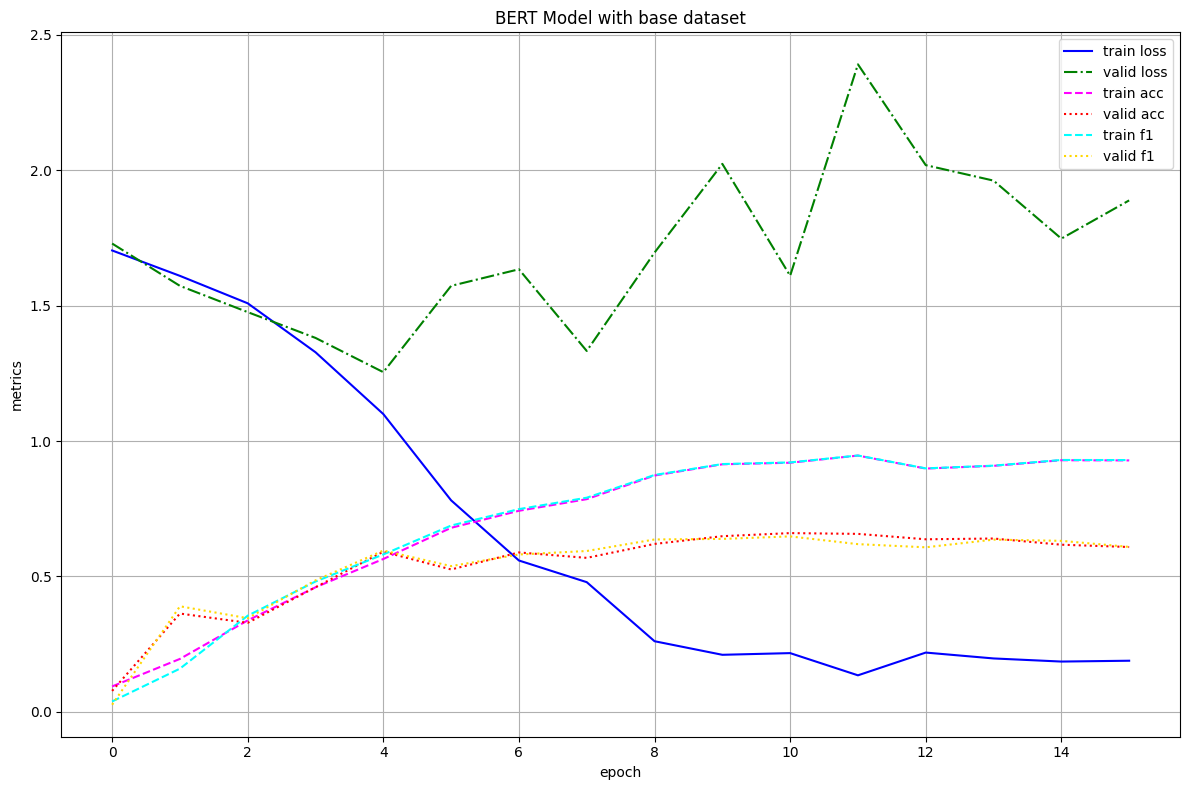

In [14]:
from utils import plot_result_curves

plot_result_curves(net, 'BERT Model with base dataset');

# Evaluation

We ran BERT against two datasets, the first version is the base dataset ('base') and the second version is the base dataset combined with scraped data to reduce our class imbalance ('combined').

This notebook looks at the 'base' dataset version. 

For the BERT Model, we use the base BertModel from Hugging Face, and add an additional linear layer for classification. For tokenization, we use the supplied BertTokenizer from HuggingFace, which is based on WordPiece. BERT has achieved state of the art performance across a wide range of natural language understanding tasks, and has been shown to produce
powerful contextualized embeddings of language in deeper layers of the model (Ethayarajh, 2019). There has also been studies showing that finetuning BERT can achieve or exceed performance of models published after it (Liu et al., 2019). 

The goal of including BERT is to see how well the base model with some additional basic fine tuning using our dataset compared to the previous models we have tested. Note that our implementation differs from the cited papers, mainly because we wanted to see keep the model as close as we can to its default to see how it compares to our previous models in terms of both performance and effort.

Using the base dataset, we can see a divergence in loss, despite a decent f1 score on our validation set. Epoch 11 is where our validation weighted f1 score starts to dip and so we will use the model at that point for inference. However, the divergence in validation and training loss does suggest that there was some overfitting starting from epoch 4. Given that LSTM also showed signs of overfitting until we introduced our augmented dataset, we will also train BERT on the augmented dataset, which should be expected to help with generalization.

Kawin Ethayarajh. 2019. How Contextual are Contextualized Word Representations? Comparing the Geometry of BERT, ELMo, and GPT-2 Embeddings. In Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and the 9th International Joint Conference on Natural Language Processing (EMNLP-IJCNLP), pages 55–65, Hong Kong, China. Association for Computational Linguistics.

Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., Levy, O., Lewis, M., Zettlemoyer, L. and Stoyanov, V., 2019. Roberta: A robustly optimized bert pretraining approach. arXiv preprint arXiv:1907.11692.



In [15]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [16]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'BERT Base Dataset')

BERT Base Dataset Accuracy: 60.41%
BERT Base Dataset Weighted F1-score: 0.6104

Classification Report:
               precision    recall  f1-score   support

      center     0.2909    0.3902    0.3333        41
   lean left     0.4667    0.4590    0.4628        61
  lean right     0.3396    0.4865    0.4000        37
        left     0.7870    0.7658    0.7763       222
       right     0.6038    0.4211    0.4961        76

    accuracy                         0.6041       437
   macro avg     0.4976    0.5045    0.4937       437
weighted avg     0.6260    0.6041    0.6104       437



# Classification report summary

BERT achieves 60.41% accuracy and a weighted F1-score of 0.6104, coming close to the of FFNN with TD-IDF (72.54% accuracy, 0.6109 weighted F1). It well outperformed LSTM, suggesting that BERT is able to contextualize text much better than a purely sequence based model like LSTM. Recall that FFNN with TD-IDF also strongly outperformed our base LSTM model - this does suggest that being able to contextualize is important in classification tasks.

Do note that the tokenizer for our implementation of BERT uses a length of 128, which could potentially be unfair to compare with FFNN TD-IDF who analyses the entire article for vocabulary distributions.

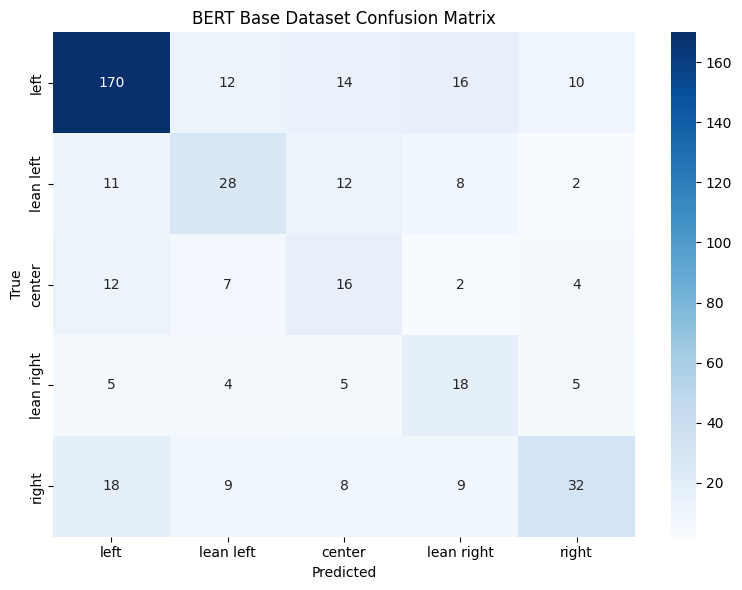

In [17]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'BERT Base Dataset');

Bert performs best on the "left" class, with 170/222 (76.6%) correct predictions, showing strong recognition of the dominant class.

Similar to LSTM, the model shows some confusion between distant ideological positions (18 "right" instances misclassified as "left"). "Right" predictions are distributed across all classes, suggesting lower precision for this label.

In [18]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for BERT Base Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for BERT Base Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[357  39]
 [ 25  16]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[344  32]
 [ 33  28]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[365  35]
 [ 19  18]]

One-vs-Rest Confusion Matrix for class 'left':
[[169  46]
 [ 52 170]]

One-vs-Rest Confusion Matrix for class 'right':
[[340  21]
 [ 44  32]]


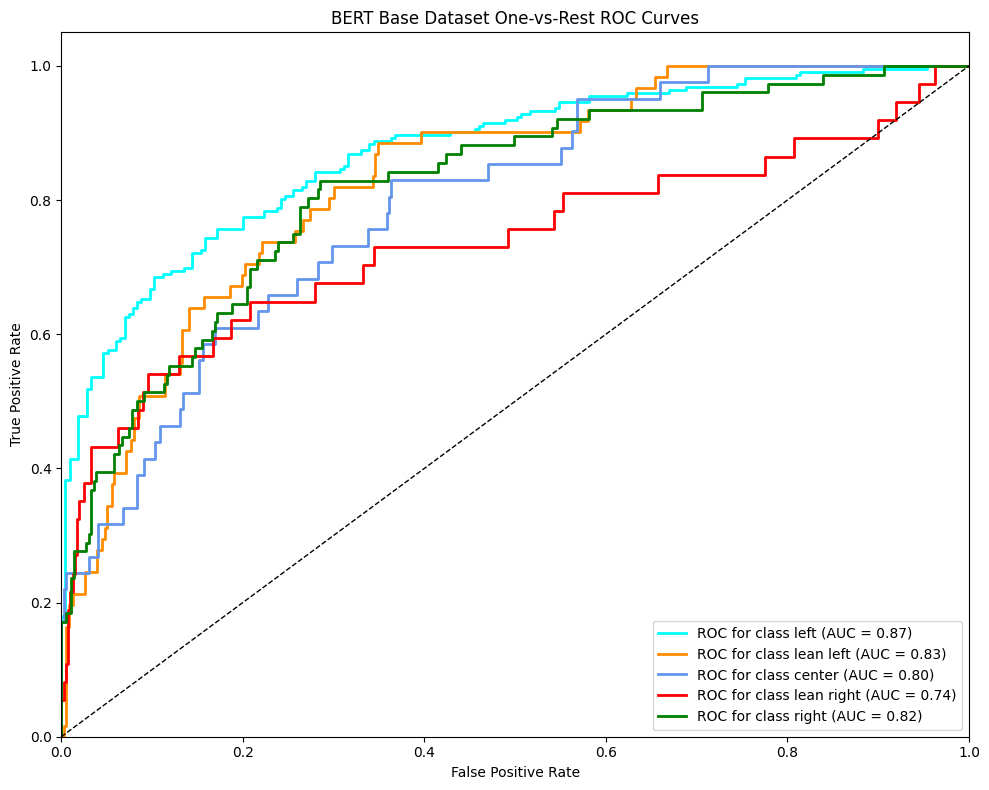

In [19]:
from utils import plot_roc

plot_roc(y_prob, net, test, classes, 'BERT Base Dataset');

ROC-AUC values for BERT are poor with a floor of 0.74 and a high of 0.87. Similar to the earlier commentary, it shows BERT performed about as good as FFNN TD-IDF and outperformed LSTM.

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| Decision Tree    | 59.27    | 60.29       |
| FFNN (TD-IDF)    | 69.79    | 68.85       |
| FFNN (GloVe)     | 32.27    | 33.72       |
| LSTM             | 37.76    | 41.46       |
| BERT             | 60.41    | 61.04       |

### Final Remarks

Overall, BERT performs as good as or better compared to our previous models. Most notably is that it performs close to FFNN TD-IDF, though FFNN TD-IDF still outperforms it. We do note that BERT takes significantly longer to train, and we did not perform any further fine tuning because of computational limits. Given unlimited resources, we would move deeper into testing different tokenizers and stretch the max_length variable for tokenized sequences further. Using Gridsearch for hyper parameter tuning was also not done in BERT's case, while it was done for our earlier models.

Overall, the results show that with little effort, BERT (and likely other models that can contextualize textual data). To further test our hypothesis, we will next move to an impolementation of the llama model, a newer - albeit more computationally more expensive - transformer model.. 